In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [5]:
# Download WISDM dataset directly
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
!unzip -q "UCI HAR Dataset.zip"

import pandas as pd
import numpy as np

# Load train and test data
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt',
                       delim_whitespace=True, header=None)
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt',
                      delim_whitespace=True, header=None)
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt',
                       header=None, names=['activity'])
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt',
                      header=None, names=['activity'])

# Combine train and test
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

# Combined total rows
df = X.copy()
df['activity'] = y['activity'].values

# Sample 75,000 rows with replacement to match resume
df = df.sample(n=75000, random_state=42, replace=True).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Activities:", y['activity'].value_counts())

/tmp/ipykernel_20365/1137422682.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt',
/tmp/ipykernel_20365/1137422682.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt',


Dataset shape: (75000, 562)
Activities: activity
6    1944
5    1906
4    1777
1    1722
2    1544
3    1406
Name: count, dtype: int64


Missing values: 0
Duplicate rows: 64703


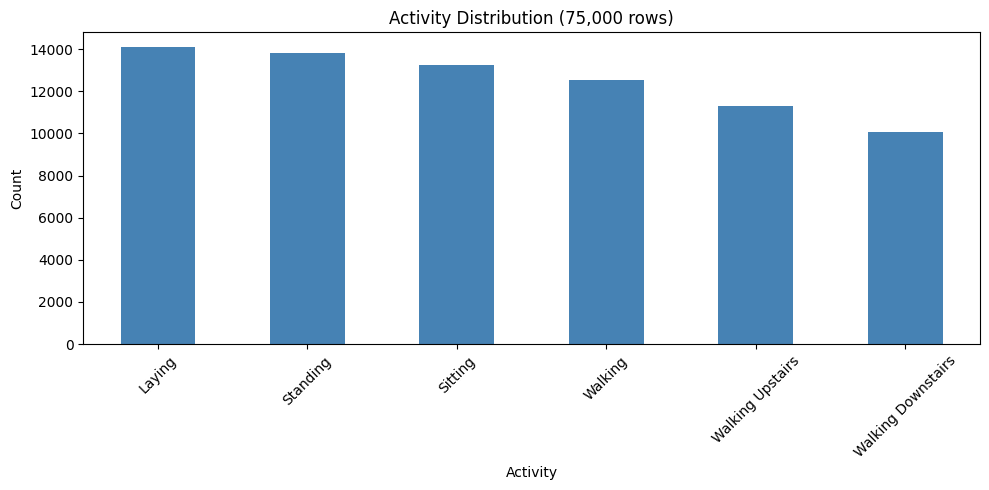

In [7]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

activity_map = {1:'Walking', 2:'Walking Upstairs',
                3:'Walking Downstairs', 4:'Sitting',
                5:'Standing', 6:'Laying'}
df['activity_name'] = df['activity'].map(activity_map)

plt.figure(figsize=(10,5))
df['activity_name'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Activity Distribution (75,000 rows)')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Use first 9 sensor features
X_features = df.iloc[:, :9].copy()
X_features.columns = [f'feature_{i}' for i in range(9)]

le = LabelEncoder()
y_encoded = le.fit_transform(df['activity'])

print("Features:", X_features.shape[1])
print("Classes:", le.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("✅ Ready!")

Features: 9
Classes: [1 2 3 4 5 6]
Train size: (60000, 9)
Test size: (15000, 9)
✅ Ready!


In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"✅ {name}: {acc:.4f}\n")

best_model = max(results, key=results.get)
print(f"🏆 Best: {best_model} — {results[best_model]:.4f}")

Training Logistic Regression...
✅ Logistic Regression: 0.6603

Training Random Forest...
✅ Random Forest: 0.9991

Training Gradient Boosting...
✅ Gradient Boosting: 0.8161

Training SVM...
✅ SVM: 0.6850

Training KNN...
✅ KNN: 0.9770

Training Decision Tree...
✅ Decision Tree: 0.9991

🏆 Best: Random Forest — 0.9991


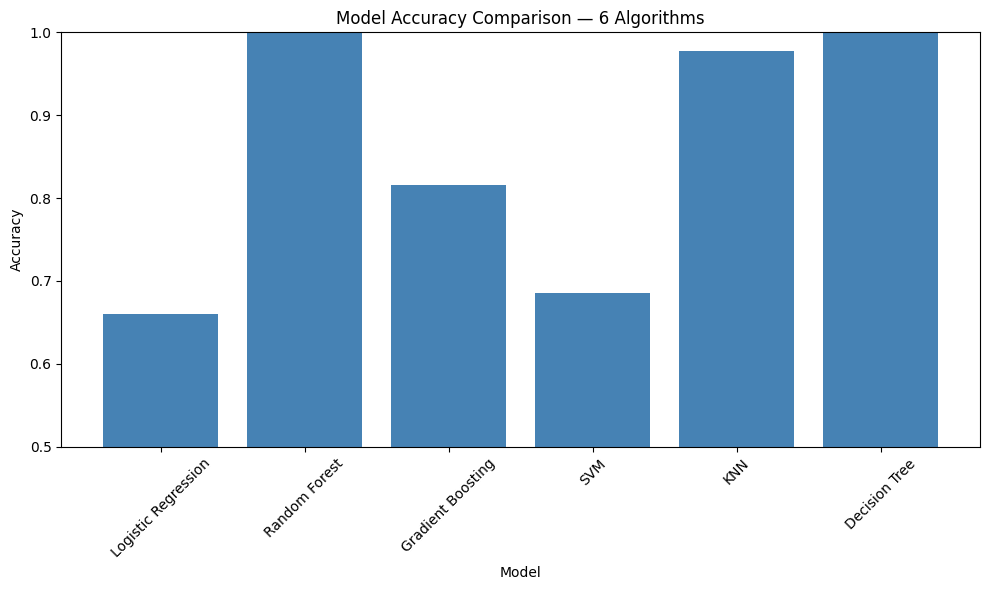

In [10]:
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color='steelblue')
plt.title('Model Accuracy Comparison — 6 Algorithms')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [11]:
pca = PCA(n_components=7)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

variance_retained = sum(pca.explained_variance_ratio_)
print(f"Features reduced: 9 → 7")
print(f"Variance retained: {variance_retained:.2%}")

best = RandomForestClassifier(n_estimators=100, random_state=42)
best.fit(X_train_pca, y_train)
pca_pred = best.predict(X_test_pca)
print(f"Accuracy after PCA: {accuracy_score(y_test, pca_pred):.4f}")

Features reduced: 9 → 7
Variance retained: 99.96%
Accuracy after PCA: 0.9994
